# Segmentez les clients d'un site e-commerce

## Contexte
Vous êtes consultant pour Olist, une entreprise brésilienne qui propose une solution de vente sur les marketplaces en ligne.

Votre objectif est de comprendre les différents types d’utilisateurs grâce à leur comportement et à leurs données personnelles.

Vous devrez fournir à l’équipe marketing une description actionable de votre segmentation et de sa logique sous-jacente pour une utilisation optimale, ainsi qu’une proposition de contrat de maintenance basée sur une analyse de la stabilité des segments au cours du temps.

## Contexte du notebook  
On s'intéresse ici aux données bruts que l'on va sélectionner et nettoyer en vue de créer un dataset concis et utile en vue de réaliser une analyse exploratoire plus poussée.

## Sommaire

- Importation des données
- Fusion et création de la base de données
- Nettoyage de la dase de données
- La segmentation RFM
    - La segemntation la RFM dans les grandes lignes
    - Le principe général de la RFM en détails
- Mise en place de la RFM
    - Données temporelles
    - Données fréquentielles
    - Données monétaires
    - Avis clients
    - CAarctéristiques techniques des produits
    - Création de la table RFM
- Analyse exploratoire
    - Histogrammes
- Sauvegarde du dataset nettoyé

# Importation des données

In [1]:
# Importation générale
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

In [2]:
# Importation des librairies pour la prédiction

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn import decomposition
# from sklearn import preprocessing
from sklearn.cluster import KMeans


from sklearn.pipeline import Pipeline
from sklearn import linear_model
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor


# Visualisation des diagrammes
from sklearn import set_config


In [3]:
# Permet d'élargir le notebook
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

In [4]:
## Import des données brutes et analyse de leur architecture

path_p4_local = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P4_'
# path_p4_cloud = 

data_01 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_customers_dataset.csv',sep=",",low_memory=False)
data_02 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_geolocation_dataset.csv',sep=",",low_memory=False)
data_03 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_order_items_dataset.csv',sep=",",low_memory=False)
data_04 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_order_payments_dataset.csv',sep=",",low_memory=False)
data_05 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_order_reviews_dataset.csv',sep=",",low_memory=False)
data_06 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_orders_dataset.csv',sep=",",low_memory=False)
data_07 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_products_dataset.csv',sep=",",low_memory=False)
data_08 = pd.read_csv(path_p4_local + r'\archive' + r'\olist_sellers_dataset.csv',sep=",",low_memory=False)
data_09 = pd.read_csv(path_p4_local + r'\archive' + r'\product_category_name_translation.csv',sep=",",low_memory=False)

In [5]:
data_0 = [data_01, data_02, data_03, data_04, data_05, data_06, data_07, data_08, data_09]

In [6]:
for i in range(0,len(data_0)):
    print('Shape of data_'+ str(i+1) + ' is '+ str(data_0[i].shape))

Shape of data_1 is (99441, 5)
Shape of data_2 is (1000163, 5)
Shape of data_3 is (112650, 7)
Shape of data_4 is (103886, 5)
Shape of data_5 is (99224, 7)
Shape of data_6 is (99441, 8)
Shape of data_7 is (32951, 9)
Shape of data_8 is (3095, 4)
Shape of data_9 is (71, 2)


In [7]:
def fillrate(dataframe, traceplot):
    # Mesure le taux de remplissage des cellules des colonnes d'un dataframe en pourcentage.
    # Renvoie un dataframe contenant les taux de remplissage pour chaque colonne
    data_appli_null = dataframe.isnull().sum(axis=0).sort_values().to_frame()
    taux_remplissage = (1 - data_appli_null/dataframe.shape[0])*100
    #taux_remplissage.columns = ['taux_remplissage']
    if traceplot == 1:
        taux_remplissage.plot.bar(figsize = (20,6),sort_columns = True)
        plt.grid()
        plt.xlabel("x: Colonnes - Tags de chaque article")
        plt.ylabel("y: Taux de remplissage d'une colonne en %")
        plt.show()
    return taux_remplissage

In [8]:
for i in range(0,len(data_0)):
    print('Shape of data_'+ str(i+1) + ' is '+ str(data_0[i].shape))
    print(str(data_0[i].head()))

Shape of data_1 is (99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
Shape of data_2 is (1000163, 5)
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                      

# Fusion et création de la base de données

On va d'abord créer une nouvelle base de données qui centralisera toute nos données , que l'on remplira en joignant les différentes tables que nous à fourni l'entreprise.
Pour ce faire, on utilisera les clés de jointure entre chaque table de données, représentées sur le schéma de description de la base de l'entreprise.
A chaque jointure, on regardera les colonnes qui ne nous intéresse pas en vue de les supprimer.

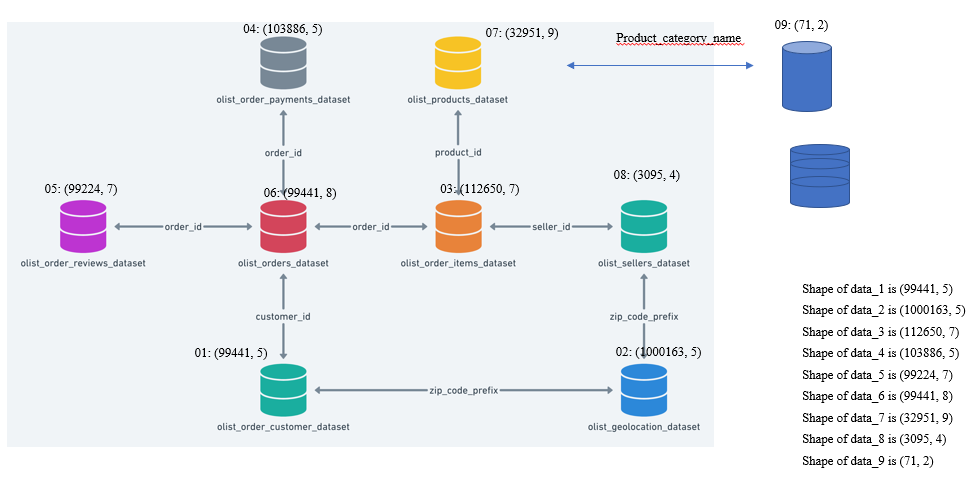

In [9]:
data=pd.DataFrame([])

A chaque jointure, on récupère un une partie ddes varaiables de la table. Si ce n'est pas possible, on crée une liste des noms de colonnes que l'on désire supprimer lorsque qu'on aura rassembler toute les tables en un seul dataset. Cette liste, on va la remplir au fur et à mesure qu'on joint nos tables.

In [10]:
list_to_drop = []

On va commencer par la table qui est connectée avec le plus de tables, c'est-à-dire la table 6:

In [11]:
data_06

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


On décide de ne garder que les dates où le client réalise la commande, et la date où il reçoit effectivement la commande. Le statut de la commande pourrait être intéressant à garder.

In [12]:
data = data_06[['order_id','customer_id','order_purchase_timestamp','order_delivered_customer_date']]

In [13]:
data

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,2017-03-17 15:08:01
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,2018-02-28 17:37:56
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,2017-09-21 11:24:17
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-25 23:32:54


On regarde ensuite la table 5:

In [14]:
data_05

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


Seules les données numériques nous intéressent ici:

In [15]:
data = pd.merge(data,data_05[['order_id','review_score']],how='left',on='order_id') 
data.shape

(99992, 5)

In [16]:
data_04

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


On garde la valeur de la transaction payée par le client, ainsi que son nombre de mensualités ou versements pour une commande, permettant de comprendre si le client possède un budget de départ conséquent.

In [17]:
data = pd.merge(data,data_04[['order_id','payment_installments','payment_value']],how='left',on='order_id') 
data.shape

(104478, 7)

In [18]:
data_03

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [19]:
data_03['order_item_id'].value_counts()

1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: order_item_id, dtype: int64

La somme de 'price' et 'freght_value' repésentent la colonne 'payment_value' de la table data_04, on ne récupèrera pas ces données. La variable 'shipping_limit_date' ne nous sera pas utile car on a déjà récupérer des dates intéressantes pour notre étude dans la table data_06. On va seulement garder les colonnes de type "id" pour effectuer les jointures de tables restantes:

In [20]:
data = pd.merge(data,data_03[['order_id','order_item_id','product_id','seller_id']],how='left',on='order_id') 
data.shape

(119143, 10)

In [21]:
data_07

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


On va garder tout les éléments numériques de cette table. La colonne "product_category_name" nous permettra de raccorder la table data_09.

In [22]:
data = pd.merge(data,data_07,how='left',on='product_id') 
data.shape

(119143, 18)

In [23]:
data_09

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


On récupère le nom anglais des catégories de produits, et on supprimera le nom brésilien, pour la facilité d'étude.

In [24]:
data = pd.merge(data,data_09,how='left',on='product_category_name')
data.shape

(119143, 19)

In [25]:
data.drop(['product_category_name'],axis=1,inplace=True)
data.shape

(119143, 18)

In [26]:
data

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,review_score,payment_installments,payment_value,order_item_id,product_id,seller_id,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,4.0,1.0,18.12,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,4.0,1.0,2.00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,4.0,1.0,18.59,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,4.0,1.0,141.46,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,5.0,3.0,179.12,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,2018-02-28 17:37:56,4.0,3.0,195.00,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,baby
119139,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,2017-09-21 11:24:17,5.0,5.0,271.01,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,home_appliances_2
119140,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-25 23:32:54,2.0,4.0,441.16,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories
119141,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-25 23:32:54,2.0,4.0,441.16,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories


### Partie géolocalisation
On aimerait ici récupérer les positions longitudinale et latérales pour les clients comme pour les vendeurs, pour estimer par la suite leur distance géographique, et voir si cela peu impacter sur le temps de livraison par exemple, et donc la satisfaction du client.
Cependant, par soucis de temps, on décide de ne pas réaliser cette étude et de la laisser en pause.  
Normalement, pour réaliser cette étude, il aurait fallu utiliser les données des tables 08, 01 et 02:

In [27]:
data_08

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [28]:
data_01

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [29]:
data_02

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


- La table data_08 possède les données de géolocalisation des vendeurs sur des adresses postales limitées: Etat, ville, code postale.
- La table data_01 possède les données de géolocalisation des clients sur des adresses postales limitées: Etat, ville, code postale.
- La table data_02 permet de raccorder les données de géolocalisation limitées précédentes à des données précises de longitude et de latitude terrestres.

 Bien qu'on n'utilisera pas ces données de géolocalisation, on utilisera la table data_01 qui nous fournit les identifiants uniques de chaque clients grâce à la jointure sur 'customer_id" avec la table data_06.

In [30]:
data = pd.merge(data,data_01[['customer_id','customer_unique_id']],how='outer',on='customer_id')
data.shape

(119143, 19)

In [31]:
data.dtypes

order_id                          object
customer_id                       object
order_purchase_timestamp          object
order_delivered_customer_date     object
review_score                     float64
payment_installments             float64
payment_value                    float64
order_item_id                    float64
product_id                        object
seller_id                         object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
customer_unique_id                object
dtype: object

# Nettoyage de la base de données
On va supprimer les colonnes qui ne nous intéresse pas et évaluer le taux de remplissage des colonnes restantes:

In [32]:
list_to_drop

[]

In [33]:
data.drop(list_to_drop,axis=1,inplace=True)

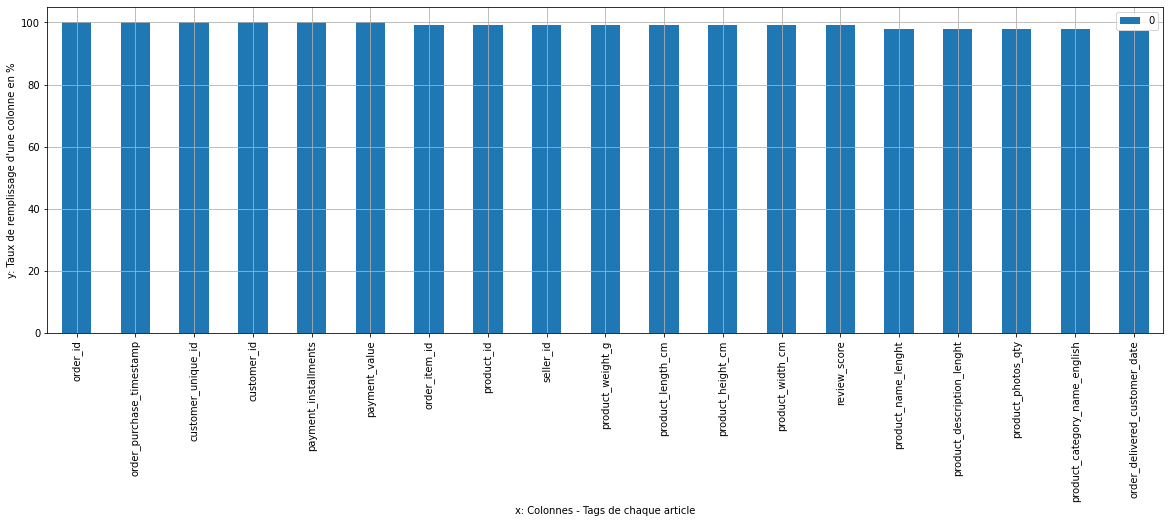

,0
order_id,100.000000
order_purchase_timestamp,100.000000
customer_unique_id,100.000000
customer_id,100.000000
payment_installments,99.997482
payment_value,99.997482
order_item_id,99.300840
product_id,99.300840
seller_id,99.300840
product_weight_g,99.284054


In [34]:
fillrate(data, 1)

La majorité des colonnes sont remplies à plus de 95%. Supprimons les pourcentages restant:

In [35]:
#data = data.dropna(axis=1,how='all') #on supprime les colonnes composées que de NaN dans chaque cellule
#on supprime les lignes possédant au moins une cellule vide
data.dropna(axis=0,how='any',inplace=True)

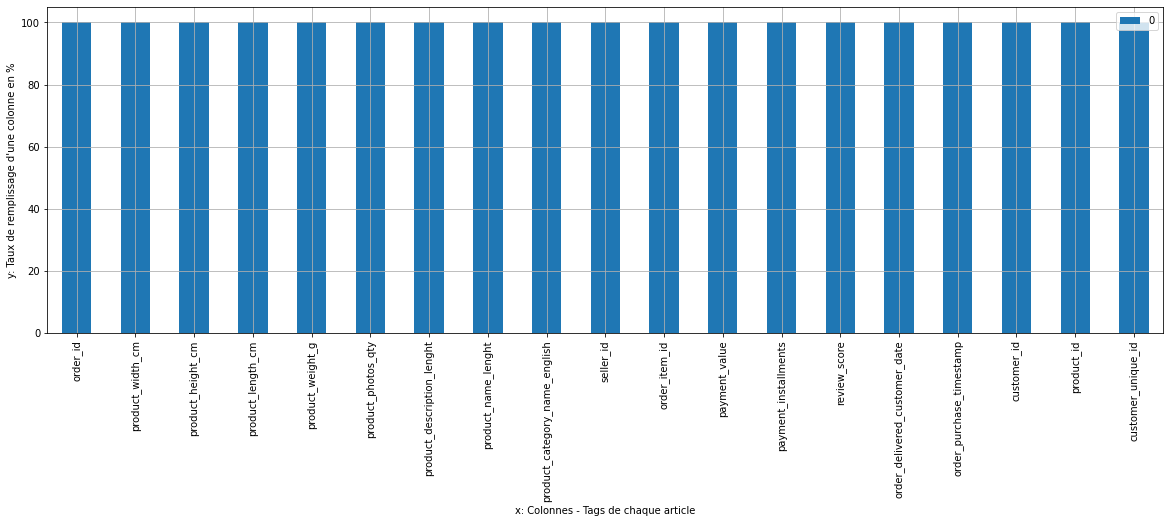

,0
order_id,100.0
product_width_cm,100.0
product_height_cm,100.0
product_length_cm,100.0
product_weight_g,100.0
product_photos_qty,100.0
product_description_lenght,100.0
product_name_lenght,100.0
product_category_name_english,100.0
seller_id,100.0


In [36]:
fillrate(data, 1)

In [37]:
data.shape

(113208, 19)

In [38]:
data.columns.to_list()

['order_id',
 'customer_id',
 'order_purchase_timestamp',
 'order_delivered_customer_date',
 'review_score',
 'payment_installments',
 'payment_value',
 'order_item_id',
 'product_id',
 'seller_id',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'customer_unique_id']

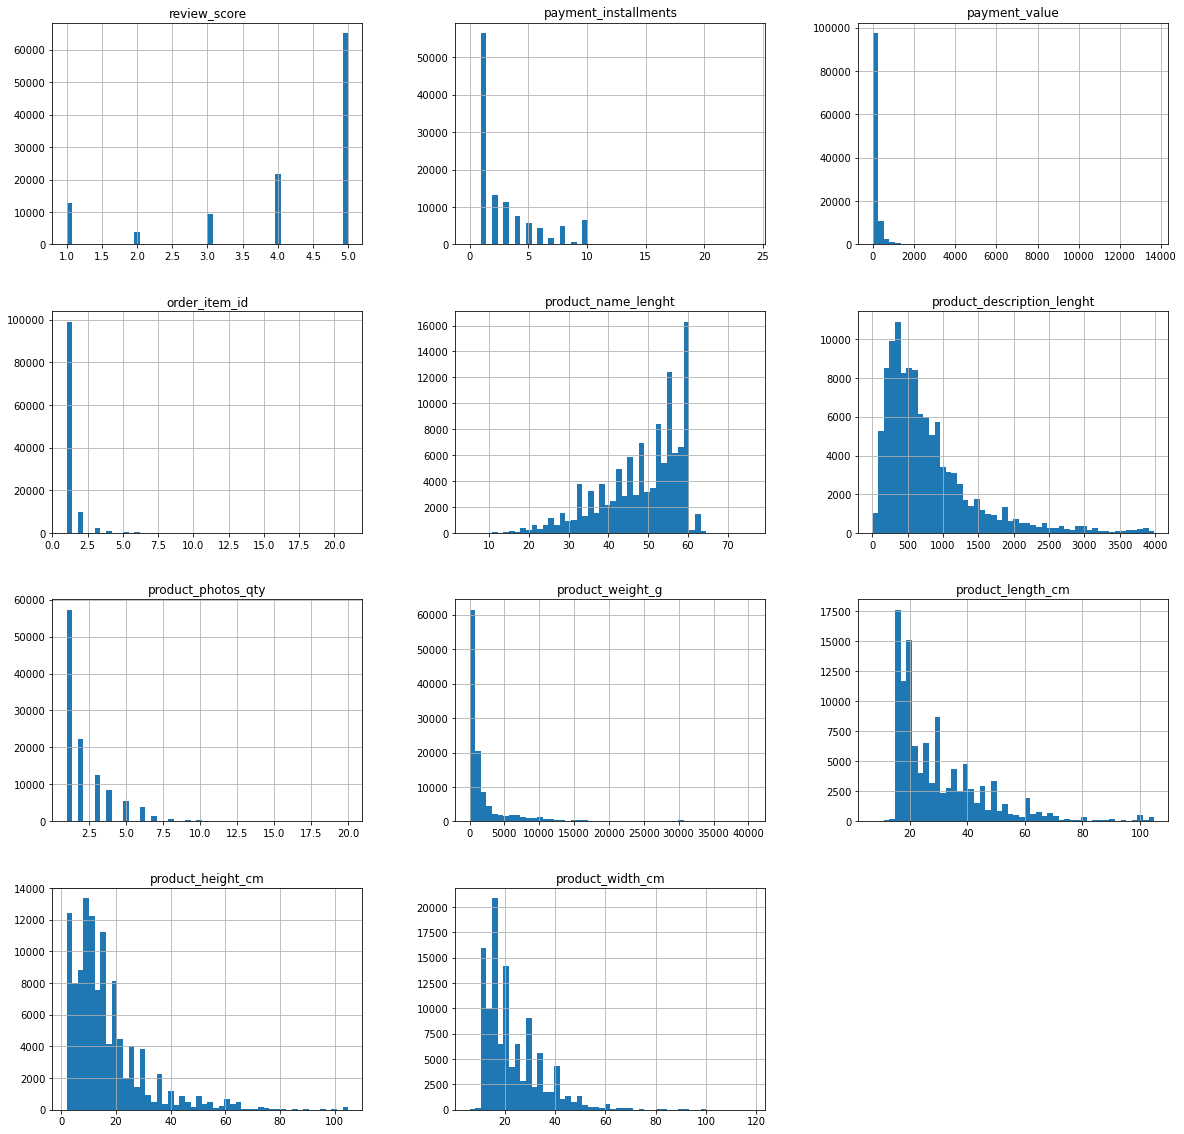

In [39]:
data.hist(bins=50,figsize=(20,20))
plt.grid()
plt.show()

On remarque qu'il y a des variables dont la quantité d'effectifs uniques est très peu étalée, notamment pour order_item_id, qui est un identifiant numérique qui s'incrémente à chaque fois qu'un nouveau produit rentre dans le panier d'une commande client. Regardons cela en détails: 

In [40]:
data['order_item_id'].value_counts()

1.0     99185
2.0      9896
3.0      2287
4.0       943
5.0       442
6.0       250
7.0        60
8.0        35
9.0        28
10.0       25
11.0       17
12.0       12
13.0        7
14.0        6
15.0        4
16.0        2
17.0        2
18.0        2
19.0        2
20.0        2
21.0        1
Name: order_item_id, dtype: int64

Il semble qu'une grande partie des clients a seulement réalisé une seule commande. Normallisons ces données:

In [41]:
data['order_item_id'].value_counts()/data.shape[0]

1.0     0.876131
2.0     0.087414
3.0     0.020202
4.0     0.008330
5.0     0.003904
6.0     0.002208
7.0     0.000530
8.0     0.000309
9.0     0.000247
10.0    0.000221
11.0    0.000150
12.0    0.000106
13.0    0.000062
14.0    0.000053
15.0    0.000035
16.0    0.000018
17.0    0.000018
18.0    0.000018
19.0    0.000018
20.0    0.000018
21.0    0.000009
Name: order_item_id, dtype: float64

Plus de 87% des clients n'ont apparement réalisés qu'un seul achat par commande. On pourra le vérifier en créant de nouvelles colonnes groupées par customer_unique_id.

In [42]:
# data['order_id'].plot.bar()

# Segmentation RFM  
## La segmentation RFM dans les grandes lignes

La méthode de segmentation RFM permet un classement des clients en fonction de leurs habitudes d'achat. On peut ainsi optimiser une stratégie marketing en fonction de nos clients.

Le classement RFM se fait en fonction de 3 critères1 :

- Récence : date du dernier achat ou dernier contact client
- Fréquence : fréquence des achats sur une période de référence donnée
- Montant : somme des achats cumulés sur cette période

## Le principe général de la segmentation RFM détaillé
L'avantage du modèle RFM est sa pertinence puisqu'il travaille sur des variables qui sont toutes observables et objectives. Elles sont toutes disponibles à partir de l'historique des commandes de chaque client. Elle nécessite pour sa mise en œuvre : une période d'analyse, des critères et des scores.

1 PÉRIODE :
Comme nous travaillons sur un historique, la période d'observation doit être fixée avec une date de début et de fin d'analyse. Généralement, elle est annuelle et divisée en 4 intervalles successifs (trimestriels).

3 CRITÈRES :
Ces variables sont classées selon 3 critères indépendants : la récence, la fréquence et le montant.

- La récence est déterminée par la proximité de la date du dernier achat avec la borne de fin de l'analyse. Plus elle est proche, meilleure elle est. Elle peut être exprimée en nombre de jours.

- La fréquence observe la régularité des achats par sous-périodes. Plus elle est forte (récurrente, au moins un achat tous les trimestres), meilleure elle est. Attention au piège. La solution qui consiste à prendre la somme des commandes (en volume) sur la période est une erreur. En effet, vous risquez de calculer deux fois le même critère Montant, puisque à panier moyen équivalent, ils seront tous deux équivalents. La puissance du modèle RFM repose sur l'observation des achats effectués au cours des 4 trimestres, de façon indépendante. Ainsi, il faut pouvoir, par exemple, dissocier les clients qui ont commandé 2 fois de suite, en début de période, de ceux qui ont commandé 2 fois de suite en fin de période.

- Le montant se calcule en valeur sur la période observée, soit la somme, soit la moyenne.


https://www.business3d.fr/segmentation-rfm/#:~:text=1%20exemple%20de%20matrice%20de%20segments%20R%C3%A9cence%20%26,%20%200%20%2056%20more%20rows%20


# Mise en place de la RFM
### Données temporelles

In [43]:
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
 
print("now =", now)

# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("date and time =", dt_string)	


now = 2022-05-08 19:40:34.844070
date and time = 08/05/2022 19:40:34


In [44]:
(pd.to_datetime(dt_string) - pd.to_datetime(data['order_purchase_timestamp'])).dt.days

0         1768
1         1768
2         1768
3         1472
4         1458
          ... 
119138    1641
119139    1804
119140    1669
119141    1669
119142    1610
Name: order_purchase_timestamp, Length: 113208, dtype: int64

In [45]:
pd.to_datetime(data['order_purchase_timestamp']).max()

Timestamp('2018-08-29 15:00:37')

On pourrait faire calculer la rcency par rapport à la fin de l'année 2018, mais on aurait des soucis si l'on doit mettre à jour le modle avec de nouveaux cliens récents. On le fait donc par rapport à la date d'aujourd'hui.

In [46]:
df_recency = data.groupby(by='customer_unique_id',as_index=False)['order_purchase_timestamp'].max()
df_recency.columns = ['customer_unique_id', 'LastPurchaseDate']
df_recency['recency_days'] = (pd.to_datetime(dt_string) - pd.to_datetime(df_recency['LastPurchaseDate'])).dt.days
df_recency['recency_years'] = df_recency['recency_days'] / 365
df_recency

,customer_unique_id,LastPurchaseDate,recency_days,recency_years
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1548,4.241096
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1551,4.249315
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1973,5.405479
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1757,4.813699
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1724,4.723288
...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1883,5.158904
91474,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1698,4.652055
91475,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,2005,5.493151
91476,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1556,4.263014


In [47]:
data['delay'] = (pd.to_datetime(data['order_delivered_customer_date']) - pd.to_datetime(data['order_purchase_timestamp'])).dt.days

df_delay = data.groupby(by='customer_unique_id',as_index=False)['delay'].mean()
df_delay.columns = ['customer_unique_id', 'mean_delay_days']
df_delay

,customer_unique_id,mean_delay_days
0,0000366f3b9a7992bf8c76cfdf3221e2,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3.0
2,0000f46a3911fa3c0805444483337064,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,20.0
4,0004aac84e0df4da2b147fca70cf8255,13.0
...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,27.0
91474,fffea47cd6d3cc0a88bd621562a9d061,30.0
91475,ffff371b4d645b6ecea244b27531430a,14.0
91476,ffff5962728ec6157033ef9805bacc48,11.0


### Données fréquentielles

In [48]:
df_frequency = data.groupby(by=['customer_unique_id'], as_index=False)['order_purchase_timestamp'].count()
df_frequency.columns = ['customer_unique_id', 'frequency']
df_frequency

,customer_unique_id,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,2
91474,fffea47cd6d3cc0a88bd621562a9d061,1
91475,ffff371b4d645b6ecea244b27531430a,1
91476,ffff5962728ec6157033ef9805bacc48,1


In [49]:
df_frequency.shape

(91478, 2)

In [50]:
df_frequency['frequency'].value_counts()/df_frequency.shape[0]

1     0.849833
2     0.109567
3     0.021207
4     0.010090
5     0.003553
6     0.003105
7     0.000732
8     0.000492
12    0.000273
10    0.000262
9     0.000262
11    0.000186
14    0.000098
24    0.000077
15    0.000066
13    0.000044
20    0.000033
21    0.000033
18    0.000011
19    0.000011
22    0.000011
26    0.000011
16    0.000011
38    0.000011
75    0.000011
35    0.000011
Name: frequency, dtype: float64

84% des clients ont réalisés une seule commande, 10% ont réalisés 2 commandes et ensuite moins de 1% pour les commandes supérieures.  

### Données monétaires

In [51]:
#data['Total'] = data['payment_value']
df_monetary = data.groupby(by='customer_unique_id', as_index=False)['payment_value'].sum()
df_monetary.columns = ['customer_unique_id', 'monetary']
df_monetary.head()

,customer_unique_id,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [52]:
df_payment_installments = data.groupby(by='customer_unique_id', as_index=False)['payment_installments'].mean()
df_payment_installments.columns = ['customer_unique_id', 'mean_payment_installments']
df_payment_installments.head()

,customer_unique_id,mean_payment_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1.0
2,0000f46a3911fa3c0805444483337064,8.0
3,0000f6ccb0745a6a4b88665a16c9f078,4.0
4,0004aac84e0df4da2b147fca70cf8255,6.0


### Avis clients

In [2]:
df_review =  data.groupby(by=['customer_unique_id'], as_index=False)['review_score'].agg(['mean', 'min', 'max']).reset_index()
df_review.columns = ['customer_unique_id', 'mean_review','min_review','max_review']
df_review

### Caractéristiques techniques des produits

In [54]:
data['volume'] = data['product_length_cm'] * data['product_height_cm'] * data['product_width_cm'] 
df_volume =   data.groupby(by=['customer_unique_id'], as_index=False)['volume'].agg(['mean', 'min', 'max']).reset_index()
df_volume.columns = ['customer_unique_id', 'mean_volume_cm3','min_volume_cm3','max_volume_cm3']
df_volume

,customer_unique_id,mean_volume_cm3,min_volume_cm3,max_volume_cm3
0,0000366f3b9a7992bf8c76cfdf3221e2,7616.0,7616.0,7616.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5148.0,5148.0,5148.0
2,0000f46a3911fa3c0805444483337064,43750.0,43750.0,43750.0
3,0000f6ccb0745a6a4b88665a16c9f078,1045.0,1045.0,1045.0
4,0004aac84e0df4da2b147fca70cf8255,528.0,528.0,528.0
...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,251625.0,251625.0,251625.0
91474,fffea47cd6d3cc0a88bd621562a9d061,32076.0,32076.0,32076.0
91475,ffff371b4d645b6ecea244b27531430a,3315.0,3315.0,3315.0
91476,ffff5962728ec6157033ef9805bacc48,4480.0,4480.0,4480.0


In [55]:
df_weight =   data.groupby(by=['customer_unique_id'], as_index=False)['product_weight_g'].agg(['mean', 'min', 'max']).reset_index()
df_weight.columns = ['customer_unique_id', 'mean_weight_g','min_weight_g','max_weight_g']
df_weight

,customer_unique_id,mean_weight_g,min_weight_g,max_weight_g
0,0000366f3b9a7992bf8c76cfdf3221e2,1500.0,1500.0,1500.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,375.0,375.0,375.0
2,0000f46a3911fa3c0805444483337064,1500.0,1500.0,1500.0
3,0000f6ccb0745a6a4b88665a16c9f078,150.0,150.0,150.0
4,0004aac84e0df4da2b147fca70cf8255,6050.0,6050.0,6050.0
...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,30000.0,30000.0,30000.0
91474,fffea47cd6d3cc0a88bd621562a9d061,1720.0,1720.0,1720.0
91475,ffff371b4d645b6ecea244b27531430a,600.0,600.0,600.0
91476,ffff5962728ec6157033ef9805bacc48,444.0,444.0,444.0


In [56]:
df_name_lenght =   data.groupby(by=['customer_unique_id'], as_index=False)['product_name_lenght'].agg(['mean']).reset_index()
df_name_lenght.columns = ['customer_unique_id', 'mean_product_name_lenght']
df_name_lenght

,customer_unique_id,mean_product_name_lenght
0,0000366f3b9a7992bf8c76cfdf3221e2,60.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,56.0
2,0000f46a3911fa3c0805444483337064,49.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.0
4,0004aac84e0df4da2b147fca70cf8255,58.0
...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,54.0
91474,fffea47cd6d3cc0a88bd621562a9d061,37.0
91475,ffff371b4d645b6ecea244b27531430a,57.0
91476,ffff5962728ec6157033ef9805bacc48,35.0


In [57]:
df_product_description_lenght =   data.groupby(by=['customer_unique_id'], as_index=False)['product_description_lenght'].agg(['mean']).reset_index()
df_product_description_lenght.columns = ['customer_unique_id', 'mean_product_description_lenght']
df_product_description_lenght

,customer_unique_id,mean_product_description_lenght
0,0000366f3b9a7992bf8c76cfdf3221e2,236.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,635.0
2,0000f46a3911fa3c0805444483337064,177.0
3,0000f6ccb0745a6a4b88665a16c9f078,1741.0
4,0004aac84e0df4da2b147fca70cf8255,794.0
...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,478.5
91474,fffea47cd6d3cc0a88bd621562a9d061,506.0
91475,ffff371b4d645b6ecea244b27531430a,716.0
91476,ffff5962728ec6157033ef9805bacc48,591.0


In [58]:
df_product_photos_qty =   data.groupby(by=['customer_unique_id'], as_index=False)['product_photos_qty'].agg(['mean']).reset_index()
df_product_photos_qty.columns = ['customer_unique_id', 'mean_product_photos_qty']
df_product_photos_qty

,customer_unique_id,mean_product_photos_qty
0,0000366f3b9a7992bf8c76cfdf3221e2,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1.0
2,0000f46a3911fa3c0805444483337064,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,5.0
4,0004aac84e0df4da2b147fca70cf8255,3.0
...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,1.0
91474,fffea47cd6d3cc0a88bd621562a9d061,2.0
91475,ffff371b4d645b6ecea244b27531430a,5.0
91476,ffff5962728ec6157033ef9805bacc48,3.0


In [59]:
# Most frequent for product_category_name_english
data.groupby('customer_unique_id')['product_category_name_english'].agg(lambda x: x.value_counts().index[0])

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    bed_bath_table
0000b849f77a49e4a4ce2b2a4ca5be3f     health_beauty
0000f46a3911fa3c0805444483337064        stationery
0000f6ccb0745a6a4b88665a16c9f078         telephony
0004aac84e0df4da2b147fca70cf8255         telephony
                                         ...      
fffcf5a5ff07b0908bd4e2dbc735a684     health_beauty
fffea47cd6d3cc0a88bd621562a9d061              baby
ffff371b4d645b6ecea244b27531430a              auto
ffff5962728ec6157033ef9805bacc48     watches_gifts
ffffd2657e2aad2907e67c3e9daecbeb         perfumery
Name: product_category_name_english, Length: 91478, dtype: object

In [60]:
data['product_category_name_english'].value_counts()

bed_bath_table               11685
health_beauty                 9749
sports_leisure                8736
furniture_decor               8558
computers_accessories         7926
                             ...  
arts_and_craftmanship           24
la_cuisine                      15
cds_dvds_musicals               14
fashion_childrens_clothes        7
security_and_services            2
Name: product_category_name_english, Length: 71, dtype: int64

### Création de la table RFM

In [61]:
data_rfm =df_monetary.merge(df_frequency.merge(df_recency[['customer_unique_id', 'recency_days']].merge(df_payment_installments.merge(df_review.merge(df_volume.merge(df_weight,on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id')

data_rfm

,customer_unique_id,monetary,frequency,recency_days,mean_payment_installments,mean_review,min_review,max_review,mean_volume_cm3,min_volume_cm3,max_volume_cm3,mean_weight_g,min_weight_g,max_weight_g
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,5.0,5.0,7616.0,7616.0,7616.0,1500.0,1500.0,1500.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,4.0,4.0,5148.0,5148.0,5148.0,375.0,375.0,375.0
2,0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,3.0,3.0,43750.0,43750.0,43750.0,1500.0,1500.0,1500.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,4.0,4.0,1045.0,1045.0,1045.0,150.0,150.0,150.0
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,5.0,5.0,528.0,528.0,528.0,6050.0,6050.0,6050.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,5.0,5.0,251625.0,251625.0,251625.0,30000.0,30000.0,30000.0
91474,fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,4.0,4.0,32076.0,32076.0,32076.0,1720.0,1720.0,1720.0
91475,ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,5.0,5.0,3315.0,3315.0,3315.0,600.0,600.0,600.0
91476,ffff5962728ec6157033ef9805bacc48,133.69,1,1556,5.0,5.0,5.0,5.0,4480.0,4480.0,4480.0,444.0,444.0,444.0


In [62]:
data_rfm =data_rfm.merge(df_name_lenght.merge(df_product_description_lenght.merge(df_product_photos_qty,on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id')
data_rfm

,customer_unique_id,monetary,frequency,recency_days,mean_payment_installments,mean_review,min_review,max_review,mean_volume_cm3,min_volume_cm3,max_volume_cm3,mean_weight_g,min_weight_g,max_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,5.0,5.0,7616.0,7616.0,7616.0,1500.0,1500.0,1500.0,60.0,236.0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,4.0,4.0,5148.0,5148.0,5148.0,375.0,375.0,375.0,56.0,635.0,1.0
2,0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,3.0,3.0,43750.0,43750.0,43750.0,1500.0,1500.0,1500.0,49.0,177.0,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,4.0,4.0,1045.0,1045.0,1045.0,150.0,150.0,150.0,43.0,1741.0,5.0
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,5.0,5.0,528.0,528.0,528.0,6050.0,6050.0,6050.0,58.0,794.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,5.0,5.0,251625.0,251625.0,251625.0,30000.0,30000.0,30000.0,54.0,478.5,1.0
91474,fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,4.0,4.0,32076.0,32076.0,32076.0,1720.0,1720.0,1720.0,37.0,506.0,2.0
91475,ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,5.0,5.0,3315.0,3315.0,3315.0,600.0,600.0,600.0,57.0,716.0,5.0
91476,ffff5962728ec6157033ef9805bacc48,133.69,1,1556,5.0,5.0,5.0,5.0,4480.0,4480.0,4480.0,444.0,444.0,444.0,35.0,591.0,3.0


In [63]:
data_rfm =data_rfm.merge(df_delay,on='customer_unique_id')
data_rfm

,customer_unique_id,monetary,frequency,recency_days,mean_payment_installments,mean_review,min_review,max_review,mean_volume_cm3,min_volume_cm3,max_volume_cm3,mean_weight_g,min_weight_g,max_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,5.0,5.0,7616.0,7616.0,7616.0,1500.0,1500.0,1500.0,60.0,236.0,1.0,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,4.0,4.0,5148.0,5148.0,5148.0,375.0,375.0,375.0,56.0,635.0,1.0,3.0
2,0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,3.0,3.0,43750.0,43750.0,43750.0,1500.0,1500.0,1500.0,49.0,177.0,3.0,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,4.0,4.0,1045.0,1045.0,1045.0,150.0,150.0,150.0,43.0,1741.0,5.0,20.0
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,5.0,5.0,528.0,528.0,528.0,6050.0,6050.0,6050.0,58.0,794.0,3.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,5.0,5.0,251625.0,251625.0,251625.0,30000.0,30000.0,30000.0,54.0,478.5,1.0,27.0
91474,fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,4.0,4.0,32076.0,32076.0,32076.0,1720.0,1720.0,1720.0,37.0,506.0,2.0,30.0
91475,ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,5.0,5.0,3315.0,3315.0,3315.0,600.0,600.0,600.0,57.0,716.0,5.0,14.0
91476,ffff5962728ec6157033ef9805bacc48,133.69,1,1556,5.0,5.0,5.0,5.0,4480.0,4480.0,4480.0,444.0,444.0,444.0,35.0,591.0,3.0,11.0


In [64]:
# df_monetary.merge(df_frequency.merge(df_recency[['customer_unique_id', 'recency_days']].merge(df_payment_installments.merge(df_review.merge(df_volume.merge(df_weight,on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id'),on='customer_unique_id')

In [65]:
data_rfm.columns.to_list()

['customer_unique_id',
 'monetary',
 'frequency',
 'recency_days',
 'mean_payment_installments',
 'mean_review',
 'min_review',
 'max_review',
 'mean_volume_cm3',
 'min_volume_cm3',
 'max_volume_cm3',
 'mean_weight_g',
 'min_weight_g',
 'max_weight_g',
 'mean_product_name_lenght',
 'mean_product_description_lenght',
 'mean_product_photos_qty',
 'mean_delay_days']

# Analyse exploratoire  
## Histogrammes

In [69]:
data_rfm_client = data_rfm.set_index("customer_unique_id")
data_rfm_client

,monetary,frequency,recency_days,mean_payment_installments,mean_review,min_review,max_review,mean_volume_cm3,min_volume_cm3,max_volume_cm3,mean_weight_g,min_weight_g,max_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
customer_unique_id,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,5.0,5.0,7616.0,7616.0,7616.0,1500.0,1500.0,1500.0,60.0,236.0,1.0,6.0
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,4.0,4.0,5148.0,5148.0,5148.0,375.0,375.0,375.0,56.0,635.0,1.0,3.0
0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,3.0,3.0,43750.0,43750.0,43750.0,1500.0,1500.0,1500.0,49.0,177.0,3.0,25.0
0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,4.0,4.0,1045.0,1045.0,1045.0,150.0,150.0,150.0,43.0,1741.0,5.0,20.0
0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,5.0,5.0,528.0,528.0,528.0,6050.0,6050.0,6050.0,58.0,794.0,3.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,5.0,5.0,251625.0,251625.0,251625.0,30000.0,30000.0,30000.0,54.0,478.5,1.0,27.0
fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,4.0,4.0,32076.0,32076.0,32076.0,1720.0,1720.0,1720.0,37.0,506.0,2.0,30.0
ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,5.0,5.0,3315.0,3315.0,3315.0,600.0,600.0,600.0,57.0,716.0,5.0,14.0


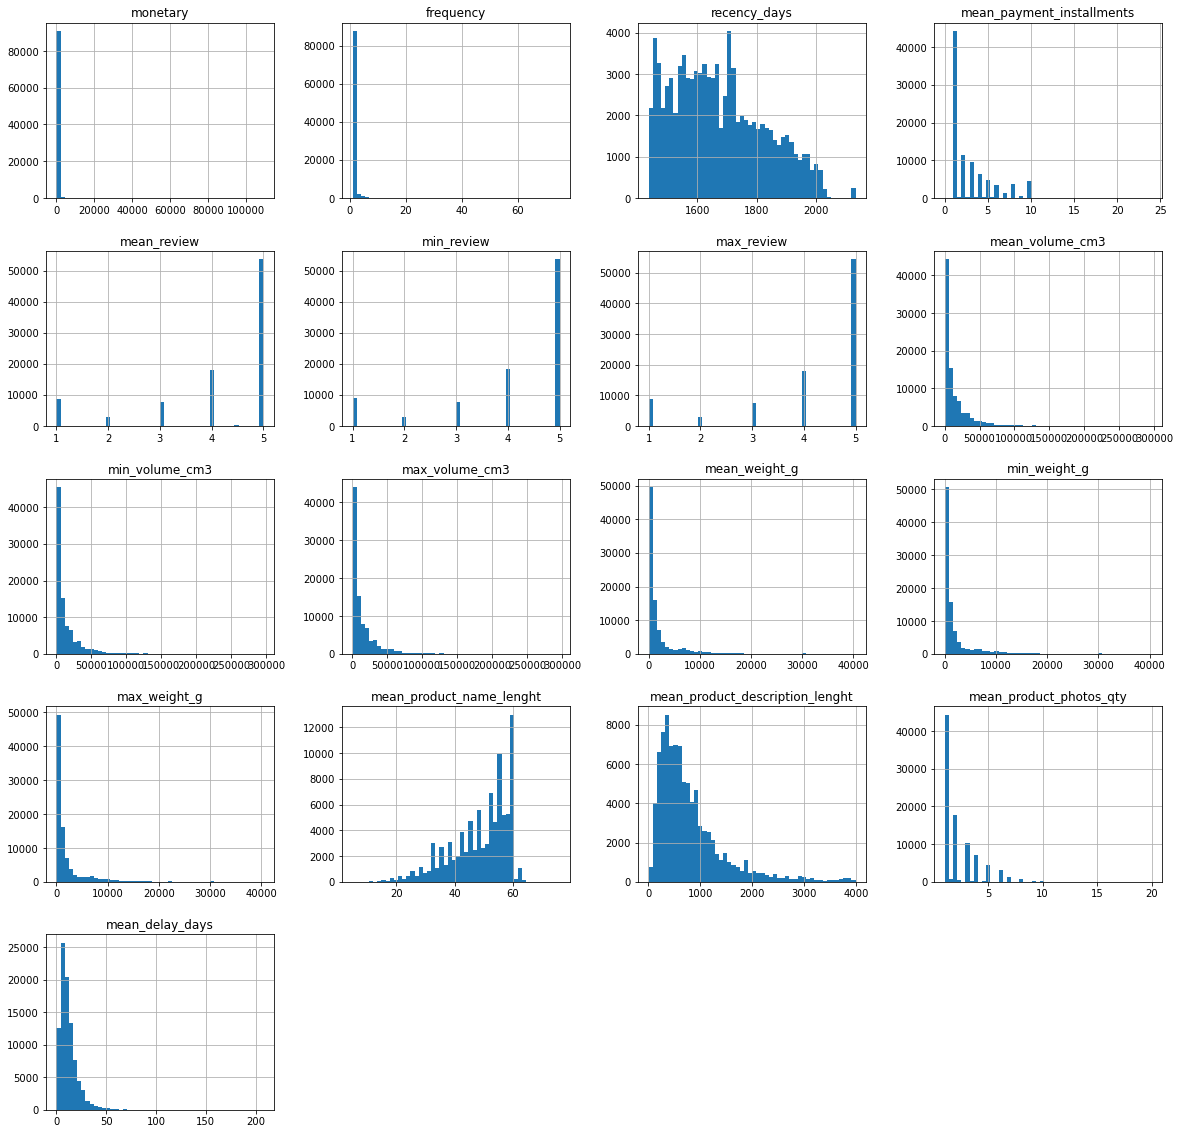

In [70]:
data_rfm_client.hist(bins=50,figsize=(20,20))
plt.grid()
plt.show()

Du fait de la forte proportion de clients qui ont effectués une seule commande d'article, les valeurs min, max et moyennes de plusieurs données sont identiques pour plusierus variables. Il sera possible d'en supprimer plusieurs.   
On peut déjà constater qu'il n'y a aucune valeur négative. Les échelles de meusures sont très étalées et les variables ne sont pas gaussiennes.
Appliquons une transformation sur nos données pour les standardiser et les rendre plus gaussiennes:

In [71]:
data_rfm_client.drop(['min_review','max_review','min_volume_cm3','max_volume_cm3','min_weight_g','max_weight_g'],axis=1,inplace=True)

In [72]:
# data_rfm_client.drop(['mean_volume_cm3','mean_weight_g','mean_product_name_lenght','mean_product_description_lenght'],axis=1,inplace=True)
# data_rfm_client

In [73]:
# data_rfm_client.drop(['mean_product_photos_qty'],axis=1,inplace=True)
# data_rfm_client

# Sauvegarde du dataset nettoyé
On sauvegarde le nouveau dataset

In [81]:
# saving the dataframe
data_rfm_client.to_csv('D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P4_\\data_clean.csv', sep='\t', index=True)

On décide ici de sauvegarder la table df_recency pour pouvoir utiliser la colonne LastPurchaseDate dans le notebook de simulation.

In [83]:
# saving the dataframe
df_recency.to_csv('D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P4_\\df_recency.csv', sep='\t', index=False)